In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score , mean_squared_error
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')


In [14]:
# import the dataset as df
df = pd.read_csv("Ecommerce Customers")

In [15]:
# Analyzing the dataset
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [16]:
# Analzing the structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [17]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


EDA

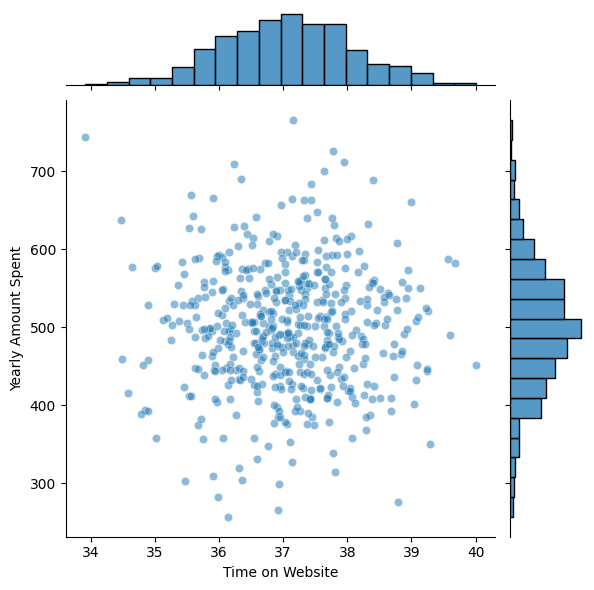

In [19]:
sns.jointplot(x='Time on Website', y='Yearly Amount Spent', data=df, alpha=0.5)

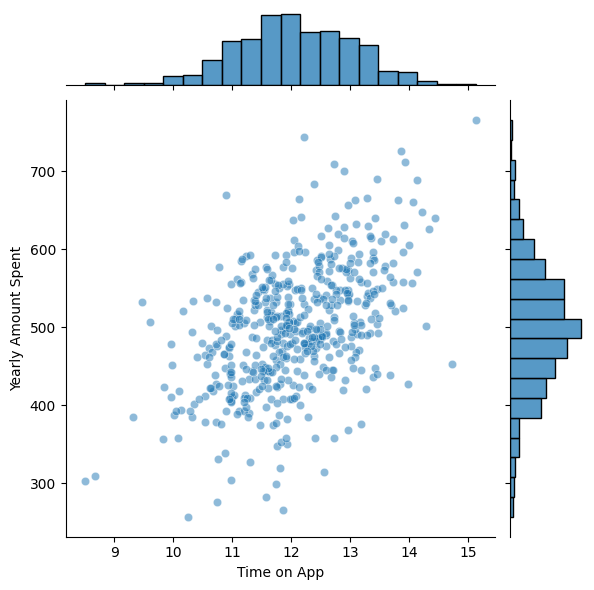

In [20]:
sns.jointplot(x='Time on App', y='Yearly Amount Spent', data=df, alpha=0.5)

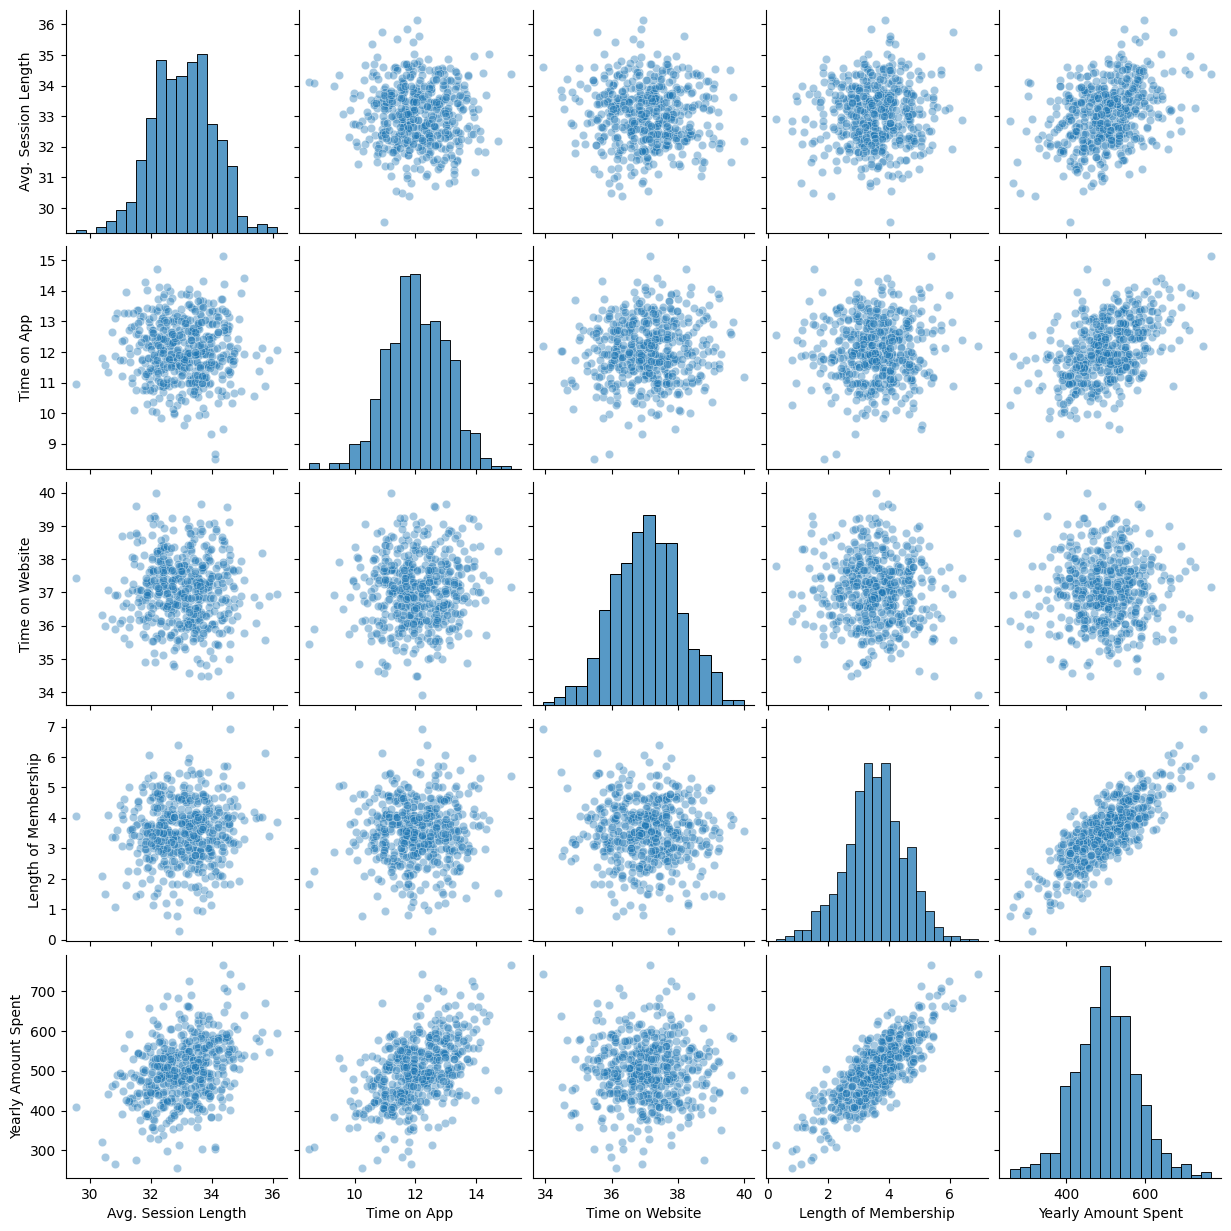

In [24]:
sns.pairplot(df, kind='scatter', plot_kws={'alpha': 0.4})

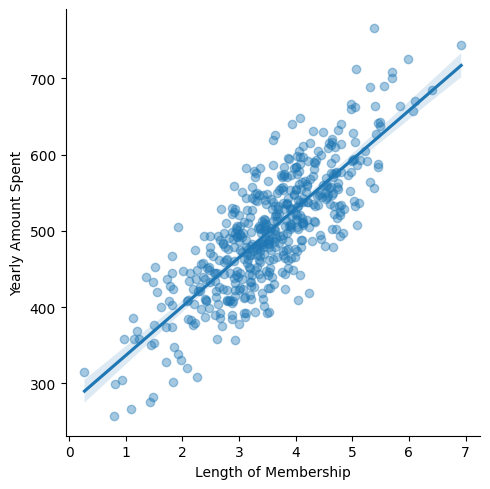

In [26]:
sns.lmplot(x='Length of Membership', y='Yearly Amount Spent', data=df, scatter_kws={'alpha':0.4})

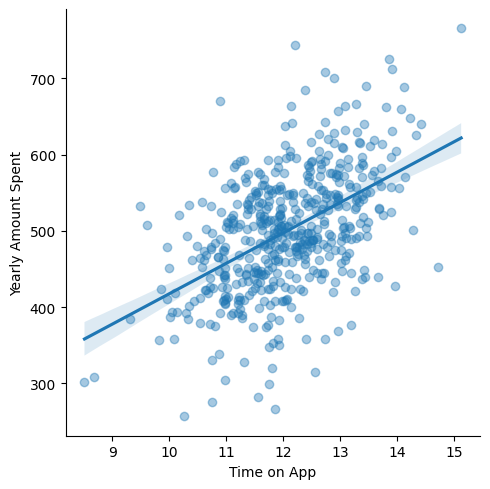

In [27]:
sns.lmplot(x='Time on App', y='Yearly Amount Spent', data=df, scatter_kws={'alpha':0.4})

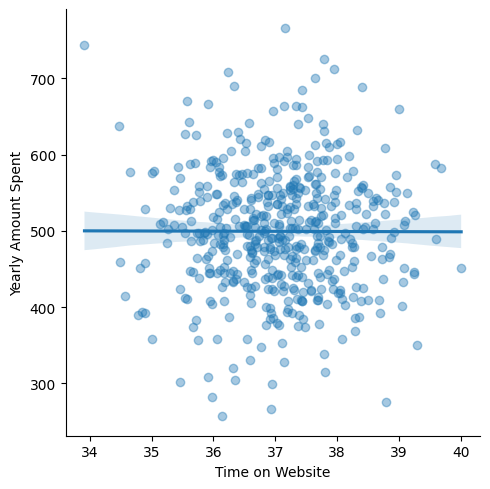

In [28]:
sns.lmplot(x='Time on Website', y='Yearly Amount Spent', data=df, scatter_kws={'alpha':0.4})

Spliting the data

In [30]:
df.drop('Email', axis=1, inplace=True)
df.drop('Address', axis=1, inplace=True)
df.drop('Avatar', axis=1, inplace=True)

In [32]:
x= df.drop('Yearly Amount Spent', axis=1)
y= df['Yearly Amount Spent']

In [34]:
scale = StandardScaler()
x = scale.fit_transform(x)

In [35]:
x

array([[ 1.45635117,  0.60728003,  2.49358859,  0.55010651],
       [-1.13650215, -0.94946372,  0.20655573, -0.87092735],
       [-0.05272322, -0.72713923,  0.04968115,  0.5720669 ],
       ...,
       [-0.40987204, -0.55685385,  1.26018697,  1.42726105],
       [ 0.27159708,  0.34124841, -0.21829075, -1.19904197],
       [ 0.66842216,  0.36882066, -1.27732288, -0.79967926]])

In [44]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [45]:
# linear model
model = LinearRegression()

In [46]:
# using linear model
model.fit(x_train, y_train)

LinearRegression()

In [49]:
# checking coefficents
model.coef_

array([25.38048395, 38.52241606,  0.31332774, 61.79022522])

Using ridge lasso and elastic to check coefficent

In [53]:
ridge = Ridge()
lasso = Lasso()
elastic = ElasticNet()

In [54]:
ridge.fit(x_train, y_train)
lasso.fit(x_train, y_train)
elastic.fit(x_train, y_train)

ElasticNet()

In [55]:
#checking predictions on each
ridge_predictions = ridge.predict(x_test)
lasso_predictions = lasso.predict(x_test)
elastic_predictions = elastic.predict(x_test)

In [57]:
#checking coefficents of ridge
ridge.coef_

array([25.31880961, 38.4327666 ,  0.31384549, 61.65099456])

In [58]:
#checking coefficent od lasso
lasso.coef_

array([24.3752714 , 37.57461394,  0.        , 60.91156002])

In [59]:
# checking coefficent of elastic
elastic.coef_

array([16.74098424, 25.97113733,  0.        , 42.24140487])

In [47]:
# predictions from the tarined model
linear_predictions = model.predict(x_test)

Model Evaluation

In [48]:

r2_score(y_test, linear_predictions)

0.9778130629184126

In [43]:
mean_squared_error(y_test, linear_predictions)

109.86374118394042

r2_score  = 97%
mean_square_error = 109

Evaluating elastic model

In [60]:
elastic_r2 = r2_score(y_test, elastic_predictions)
elastic_mse = mean_squared_error(y_test, elastic_predictions)

In [61]:
elastic_r2

0.8804161689903826

In [62]:
elastic_mse

592.1469471659352

In [63]:
#r2_score = 88%
#mse = 592

Evaluating ridge Model

In [64]:
ridge_r2 = r2_score(y_test, ridge_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)

In [65]:
ridge_r2

0.9778954738144373

In [66]:
ridge_mse

109.45566460634414

In [67]:
# r2_score = 97%
# mse = 109

Evaluating lasso Model

In [68]:
lasso_r2 = r2_score(y_test, lasso_predictions)
lasso_mse = mean_squared_error(y_test, lasso_predictions)

In [69]:
lasso_r2

0.977670404669426

In [70]:
lasso_mse

110.57014643883355

In [ ]:
# r2_score = 97%
# mse = 110

Ridge lasso and elastic regression are not changing much

In [77]:
# now training the model on polynomial regression
poly_model = PolynomialFeatures(degree=2)

In [78]:
# traing the polynomial model
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [79]:
# Using polynomial model
poly_model.fit(x_train, y_train)

PolynomialFeatures()

In [80]:
# predictions of ploynomial
poly_predictions = model.predict(x_test)

In [81]:
# Evaluating the polynomial model
poly_r2 = r2_score(y_test, poly_predictions)
poly_mse = mean_squared_error(y_test, poly_predictions)

In [82]:
poly_r2

0.9778130629184126

In [83]:
poly_mse

109.86374118394042

In [84]:
# using degree 3
poly_model = PolynomialFeatures(degree=3)

In [85]:
# traing the polynomial model
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [86]:
# Using polynomial model
poly_model.fit(x_train, y_train)

PolynomialFeatures(degree=3)

In [87]:
# predictions of ploynomial
poly_predictions = model.predict(x_test)

In [88]:
# Evaluating the polynomial model
degeree3_poly_r2 = r2_score(y_test, poly_predictions)
degree3_poly_mse = mean_squared_error(y_test, poly_predictions)

In [89]:
degeree3_poly_r2

0.9778130629184126

In [90]:
degree3_poly_mse

109.86374118394042

Polynomial linear regression is producing same output,SO


Simple Linear Regression is best for this model